##DA3

In [1]:
import os
import math
import random
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision import transforms
from torchvision.datasets import Flowers102

from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = (
    "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
)
print("Using device:", DEVICE)

Using device: cuda


Корпус цветных изображений - Oxford Flowers-102


100%|██████████| 345M/345M [00:18<00:00, 18.6MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.57MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 5.57MB/s]


Total flowers in train split: 1020
Будет использовано: 240 картинок


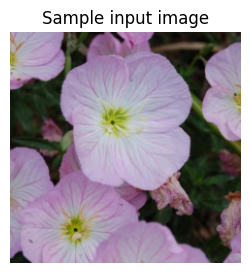

In [2]:
DATA_ROOT = Path("./data")
SYNTH_DIR = Path("./synth_depth")
DATA_ROOT.mkdir(exist_ok=True)
SYNTH_DIR.mkdir(exist_ok=True)

IMG_SIZE = 128
TEACHER_SIZE = 224
N_IMAGES = 240

raw_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(TEACHER_SIZE),
])

flowers = Flowers102(root=str(DATA_ROOT), split="train", download=True, transform=raw_tf)
print("Total flowers in train split:", len(flowers))
indices = list(range(min(N_IMAGES, len(flowers))))
print("Будет использовано:", len(indices), "картинок")

img0, _ = flowers[0]
plt.figure(figsize=(3, 3))
plt.imshow(img0)
plt.title("Sample input image")
plt.axis("off")
plt.show()

Модель-учитель — Depth Anything 3

In [3]:
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
TEACHER_CANDIDATES = [
    "depth-anything/DA3-BASE",
    "depth-anything/DA3MONO-LARGE",
    "depth-anything/Depth-Anything-V2-Small-hf"
]

teacher = None
teacher_processor = None
TEACHER_NAME = None

for name in TEACHER_CANDIDATES:
    try:
        print("Trying teacher:", name)
        try:
            proc = AutoImageProcessor.from_pretrained(name, trust_remote_code=True)
        except Exception as e1:
            print("  AutoImageProcessor failed:", repr(e1)[:200])
            from transformers import DPTImageProcessor
            proc = DPTImageProcessor(size={"height": TEACHER_SIZE, "width": TEACHER_SIZE})
            print("  -> using fallback DPTImageProcessor with size", TEACHER_SIZE)
        mdl = AutoModelForDepthEstimation.from_pretrained(name, trust_remote_code=True).to(DEVICE)
        mdl.eval()
        teacher = mdl
        teacher_processor = proc
        TEACHER_NAME = name
        print("OK, loaded:", name)
        break
    except Exception as e:
        print("  failed:", repr(e)[:300])


n_params = sum(p.numel() for p in teacher.parameters())
print(f"Учитель: {TEACHER_NAME}, параметры: {n_params/1e6:.1f} M")

Trying teacher: depth-anything/DA3-BASE


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

  AutoImageProcessor failed: OSError("Can't load image processor for 'depth-anything/DA3-BASE'. If you were trying to load it from 'https://huggingface.co/models', make sure you don't have a local directory with the same name. Ot
  -> using fallback DPTImageProcessor with size 224
  failed: ValueError('Unrecognized model in depth-anything/DA3-BASE. Should have a `model_type` key in its config.json, or contain one of the following strings in its name: afmoe, aimv2, aimv2_vision_model, albert, align, altclip, apertus, arcee, aria, aria_text, audio-spectrogram-transformer, audioflamingo3,
Trying teacher: depth-anything/DA3MONO-LARGE


config.json:   0%|          | 0.00/845 [00:00<?, ?B/s]

...

The image processor of type `DPTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

OK, loaded: depth-anything/Depth-Anything-V2-Small-hf
Учитель: depth-anything/Depth-Anything-V2-Small-hf, параметры: 24.8 M


Генерация синтетического корпуса (RGB → depth)


In [4]:
PREVIEW_DIR = SYNTH_DIR / "preview"
PREVIEW_DIR.mkdir(exist_ok=True)

rgb_tensors = []
depth_tensors = []

to_tensor = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
])

def _extract_depth_tensor(out):

    for key in ("predicted_depth", "depth", "pred_depth", "logits"):
        if hasattr(out, key) and getattr(out, key) is not None:
            return getattr(out, key)
    if isinstance(out, dict):
        for key in ("predicted_depth", "depth", "pred_depth", "logits"):
            if key in out and out[key] is not None:
                return out[key]
    for v in (out.values() if isinstance(out, dict) else vars(out).values()):
        if torch.is_tensor(v):
            return v
    raise RuntimeError("Не нашли тензор глубины в выходе модели: " + str(type(out)))

Generating synthetic depth:   0%|          | 0/240 [00:00<?, ?it/s]

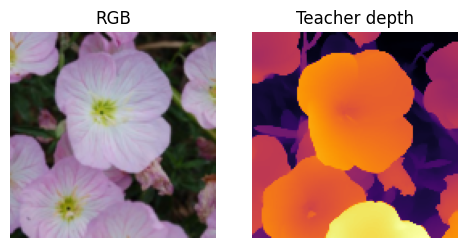

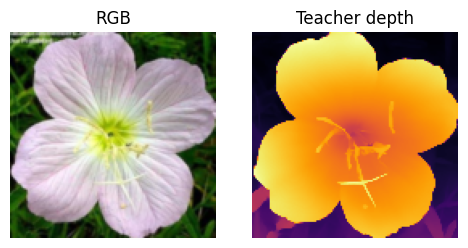

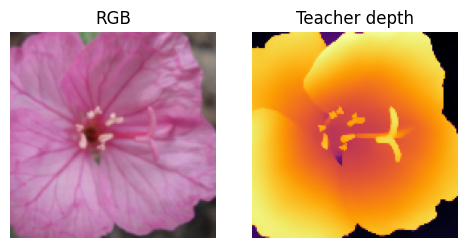

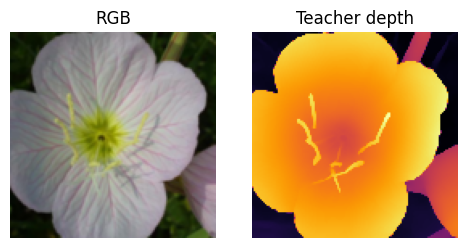

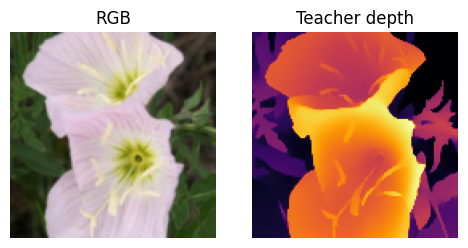

RGB tensor: torch.Size([240, 3, 128, 128]) torch.float32
Depth tensor: torch.Size([240, 128, 128]) torch.float32
Depth range: 0.0 1.0


In [5]:
@torch.no_grad()
def teacher_depth(pil_img):
    inputs = teacher_processor(images=pil_img, return_tensors="pt")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items() if torch.is_tensor(v)}
    out = teacher(**inputs)
    pred = _extract_depth_tensor(out)
    if pred.dim() == 2:
        pred = pred.unsqueeze(0).unsqueeze(0)
    elif pred.dim() == 3:
        pred = pred.unsqueeze(1)
    pred = F.interpolate(pred.float(), size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
    pred = pred.squeeze(0).squeeze(0).float().cpu()
    p_min, p_max = pred.min(), pred.max()
    if (p_max - p_min) > 1e-6:
        pred = (pred - p_min) / (p_max - p_min)
    else:
        pred = torch.zeros_like(pred)
    return pred

for i, idx in enumerate(tqdm(indices, desc="Generating synthetic depth")):
    img, _ = flowers[idx]
    depth = teacher_depth(img)
    rgb_small = to_tensor(img)

    rgb_tensors.append(rgb_small)
    depth_tensors.append(depth)
    if i < 5:
        fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))
        axes[0].imshow(rgb_small.permute(1, 2, 0).numpy())
        axes[0].set_title("RGB")
        axes[0].axis("off")
        axes[1].imshow(depth.numpy(), cmap="inferno")
        axes[1].set_title("Teacher depth")
        axes[1].axis("off")
        plt.tight_layout()
        plt.savefig(PREVIEW_DIR / f"sample_{i:03d}.png", dpi=100)
        plt.show()

rgb_tensors = torch.stack(rgb_tensors)         # (N, 3, H, W)
depth_tensors = torch.stack(depth_tensors)     # (N, H, W)

print("RGB tensor:",   rgb_tensors.shape,   rgb_tensors.dtype)
print("Depth tensor:", depth_tensors.shape, depth_tensors.dtype)
print("Depth range:",  depth_tensors.min().item(), depth_tensors.max().item())


синтетический корпус

In [6]:
synth_path = SYNTH_DIR / "synth_flowers_depth.pt"
torch.save({
    "rgb": rgb_tensors,
    "depth": depth_tensors,
    "teacher": TEACHER_NAME,
    "image_size": IMG_SIZE,
}, synth_path)
print("Saved to:", synth_path, "size_MB =", synth_path.stat().st_size / 1e6)

Saved to: synth_depth/synth_flowers_depth.pt size_MB = 62.916613


In [7]:
del teacher
del teacher_processor
import gc; gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [8]:
class SynthDepthDataset(Dataset):
    def __init__(self, rgb, depth):
        self.rgb = rgb
        self.depth = depth
    def __len__(self):
        return self.rgb.shape[0]
    def __getitem__(self, idx):
        return self.rgb[idx], self.depth[idx]

blob = torch.load(synth_path)
dataset = SynthDepthDataset(blob["rgb"], blob["depth"])
n_val = max(1, int(0.2 * len(dataset)))
n_train = len(dataset) - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))
print("Train:", n_train, "  Val:", n_val)

BATCH = 8
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0)

Train: 192   Val: 48


Студенческая модель- ViT-tiny энкодер с self-attention +  свёрточный декодер

In [9]:
class PatchEmbed(nn.Module):
    def __init__(self, in_ch=3, embed_dim=96, patch=8, img_size=IMG_SIZE):
        super().__init__()
        self.patch = patch
        self.grid = img_size // patch
        self.proj = nn.Conv2d(in_ch, embed_dim, kernel_size=patch, stride=patch)
        self.pos = nn.Parameter(torch.zeros(1, self.grid * self.grid, embed_dim))
        nn.init.trunc_normal_(self.pos, std=0.02)
    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x + self.pos

class AttnBlock(nn.Module):
    def __init__(self, dim, heads=4, mlp_ratio=2.0, drop=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, dropout=drop, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        h = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, h), nn.GELU(), nn.Dropout(drop), nn.Linear(h, dim)
        )
    def forward(self, x):
        h = self.norm1(x)
        a, _ = self.attn(h, h, h, need_weights=False)
        x = x + a
        x = x + self.mlp(self.norm2(x))
        return x

class TinyDepthFormer(nn.Module):
    def __init__(self, img_size=IMG_SIZE, patch=8, embed_dim=96, depth=4, heads=4):
        super().__init__()
        self.embed = PatchEmbed(3, embed_dim, patch, img_size)
        self.blocks = nn.ModuleList([AttnBlock(embed_dim, heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.grid = img_size // patch
        self.head = nn.Sequential(
            nn.Conv2d(embed_dim, 64, 3, padding=1), nn.GELU(),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(64, 32, 3, padding=1), nn.GELU(),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(32, 16, 3, padding=1), nn.GELU(),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(16, 1, 3, padding=1),
            nn.Sigmoid(),
        )
    def forward(self, x):
        B = x.size(0)
        t = self.embed(x)                      # (B, N, D)
        for blk in self.blocks:
            t = blk(t)
        t = self.norm(t)
        D = t.size(-1)
        f = t.transpose(1, 2).reshape(B, D, self.grid, self.grid)
        out = self.head(f)                     # (B, 1, H, W)
        return out.squeeze(1)

student = TinyDepthFormer().to(DEVICE)
n_params = sum(p.numel() for p in student.parameters())
print(f"Student параметры: {n_params/1e6:.2f} M")

xb, yb = next(iter(train_loader))
with torch.no_grad():
    pb = student(xb.to(DEVICE))
print("In:", xb.shape, "Target:", yb.shape, "Pred:", pb.shape)

Student параметры: 0.42 M
In: torch.Size([8, 3, 128, 128]) Target: torch.Size([8, 128, 128]) Pred: torch.Size([8, 128, 128])



Метрики:
* AbsRel — средняя относительная ошибка,
* RMSE — среднеквадратичная ошибка,
* δ < 1.25 — доля пикселей, у которых отношение max(p/g, g/p) меньше 1.25 (классическая depth-метрика),
* Pearson r — корреляция между предсказанной и эталонной картой (важно, потому что у нас относительная глубина).

In [10]:
EPS = 1e-6

def silog_loss(pred, target, eps=EPS):
    p = pred.clamp(min=eps)
    t = target.clamp(min=eps)
    d = torch.log(p) - torch.log(t)
    return torch.sqrt((d ** 2).mean() - 0.85 * (d.mean() ** 2) + 1e-8)

def depth_loss(pred, target):
    return F.l1_loss(pred, target) + 0.5 * silog_loss(pred, target)

def compute_metrics(pred, target, eps=EPS):
    pred = pred.detach().float().cpu().numpy().reshape(-1)
    target = target.detach().float().cpu().numpy().reshape(-1)
    p = np.clip(pred, eps, None)
    t = np.clip(target, eps, None)
    abs_rel = float(np.mean(np.abs(p - t) / t))
    rmse = float(np.sqrt(np.mean((p - t) ** 2)))
    ratio = np.maximum(p / t, t / p)
    delta1 = float(np.mean(ratio < 1.25))
    delta2 = float(np.mean(ratio < 1.25 ** 2))
    pm = p - p.mean(); tm = t - t.mean()
    denom = (np.sqrt((pm**2).sum()) * np.sqrt((tm**2).sum())) + eps
    pearson = float((pm * tm).sum() / denom)
    return {"AbsRel": abs_rel, "RMSE": rmse, "delta<1.25": delta1, "delta<1.25^2": delta2, "Pearson r": pearson}

In [11]:
EPOCHS = 25
LR = 3e-4
WD = 1e-4

optim = torch.optim.AdamW(student.parameters(), lr=LR, weight_decay=WD)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=EPOCHS)

history = {"train_loss": [], "val_loss": [], "val_absrel": [], "val_delta1": []}

best_val = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    student.train()
    tr_losses = []
    t0 = time.time()
    for xb, yb in train_loader:
        xb = xb.to(DEVICE); yb = yb.to(DEVICE)
        pb = student(xb)
        loss = depth_loss(pb, yb)
        optim.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
        optim.step()
        tr_losses.append(loss.item())
    sched.step()
    student.eval()
    vl_losses, all_p, all_t = [], [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            pb = student(xb)
            vl_losses.append(depth_loss(pb, yb).item())
            all_p.append(pb.cpu()); all_t.append(yb.cpu())
    p_all = torch.cat(all_p); t_all = torch.cat(all_t)
    m = compute_metrics(p_all, t_all)

    tr_mean = float(np.mean(tr_losses)); vl_mean = float(np.mean(vl_losses))
    history["train_loss"].append(tr_mean)
    history["val_loss"].append(vl_mean)
    history["val_absrel"].append(m["AbsRel"])
    history["val_delta1"].append(m["delta<1.25"])

    if vl_mean < best_val:
        best_val = vl_mean
        best_state = {k: v.detach().cpu().clone() for k, v in student.state_dict().items()}

    dt = time.time() - t0
    print(f"Epoch {epoch:02d}/{EPOCHS}  train={tr_mean:.4f}  val={vl_mean:.4f}  "
          f"AbsRel={m['AbsRel']:.4f}  d<1.25={m['delta<1.25']:.3f}  r={m['Pearson r']:.3f}  ({dt:.1f}s)")
if best_state is not None:
    student.load_state_dict(best_state)
print("Best val loss:", best_val)

Epoch 01/25  train=1.8163  val=1.6055  AbsRel=7228.6196  d<1.25=0.181  r=0.525  (1.5s)
Epoch 02/25  train=1.6728  val=1.5322  AbsRel=10318.1650  d<1.25=0.345  r=0.594  (0.4s)
Epoch 03/25  train=1.6001  val=1.4825  AbsRel=3918.6589  d<1.25=0.231  r=0.623  (0.4s)
Epoch 04/25  train=1.5604  val=1.4313  AbsRel=2815.6094  d<1.25=0.266  r=0.658  (0.4s)
Epoch 05/25  train=1.5107  val=1.4312  AbsRel=3179.6221  d<1.25=0.322  r=0.701  (0.4s)
Epoch 06/25  train=1.4764  val=1.4648  AbsRel=2344.4656  d<1.25=0.254  r=0.648  (0.5s)
Epoch 07/25  train=1.4592  val=1.4857  AbsRel=2694.2400  d<1.25=0.293  r=0.674  (0.4s)
Epoch 08/25  train=1.4241  val=1.4580  AbsRel=4383.4136  d<1.25=0.356  r=0.704  (0.4s)
Epoch 09/25  train=1.4200  val=1.4647  AbsRel=2755.0076  d<1.25=0.269  r=0.672  (0.4s)
Epoch 10/25  train=1.3715  val=1.4584  AbsRel=3977.5618  d<1.25=0.334  r=0.697  (0.4s)
Epoch 11/25  train=1.3556  val=1.4461  AbsRel=4448.6421  d<1.25=0.336  r=0.707  (0.4s)
Epoch 12/25  train=1.3449  val=1.4740  Abs

графики

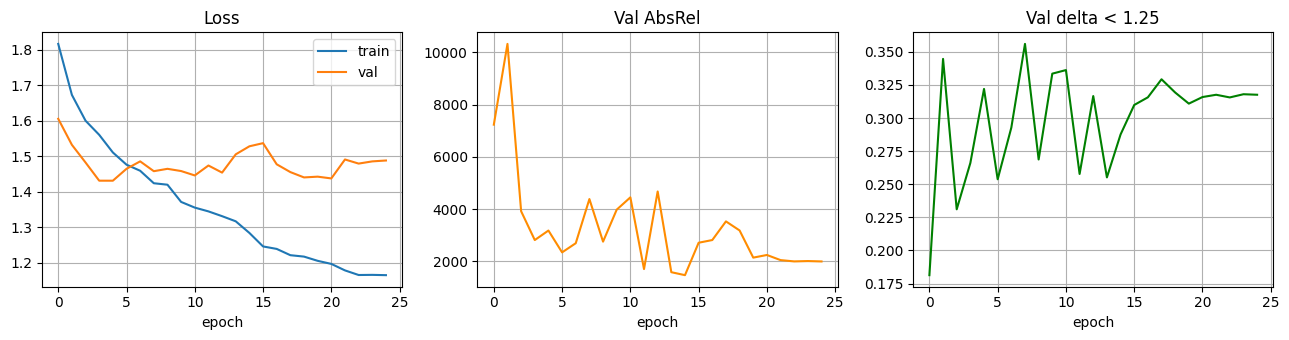

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
ax = axes[0]
ax.plot(history["train_loss"], label="train")
ax.plot(history["val_loss"], label="val")
ax.set_title("Loss"); ax.set_xlabel("epoch"); ax.legend(); ax.grid(True)
ax = axes[1]
ax.plot(history["val_absrel"], color="darkorange")
ax.set_title("Val AbsRel"); ax.set_xlabel("epoch"); ax.grid(True)
ax = axes[2]
ax.plot(history["val_delta1"], color="green")
ax.set_title("Val delta < 1.25"); ax.set_xlabel("epoch"); ax.grid(True)
plt.tight_layout()
plt.show()

In [14]:
student.eval()
all_p, all_t = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(DEVICE); yb = yb.to(DEVICE)
        pb = student(xb)
        all_p.append(pb.cpu()); all_t.append(yb.cpu())
p_all = torch.cat(all_p); t_all = torch.cat(all_t)
final_m = compute_metrics(p_all, t_all)
train_mean_depth = torch.stack([b for _, b in train_ds]).mean(dim=0)
baseline_pred = train_mean_depth.unsqueeze(0).expand_as(t_all)
baseline_m = compute_metrics(baseline_pred, t_all)

print("Student (Tiny ViT depth)")
for k, v in final_m.items():
    print(f"  {k:>14s}: {v:.4f}")
print("\nBaseline (mean-depth)")
for k, v in baseline_m.items():
    print(f"  {k:>14s}: {v:.4f}")

Student (Tiny ViT depth)
          AbsRel: 3179.6221
            RMSE: 0.2434
      delta<1.25: 0.3220
    delta<1.25^2: 0.4887
       Pearson r: 0.7012

Baseline (mean-depth)
          AbsRel: 13518.4570
            RMSE: 0.2894
      delta<1.25: 0.1935
    delta<1.25^2: 0.4091
       Pearson r: 0.4549


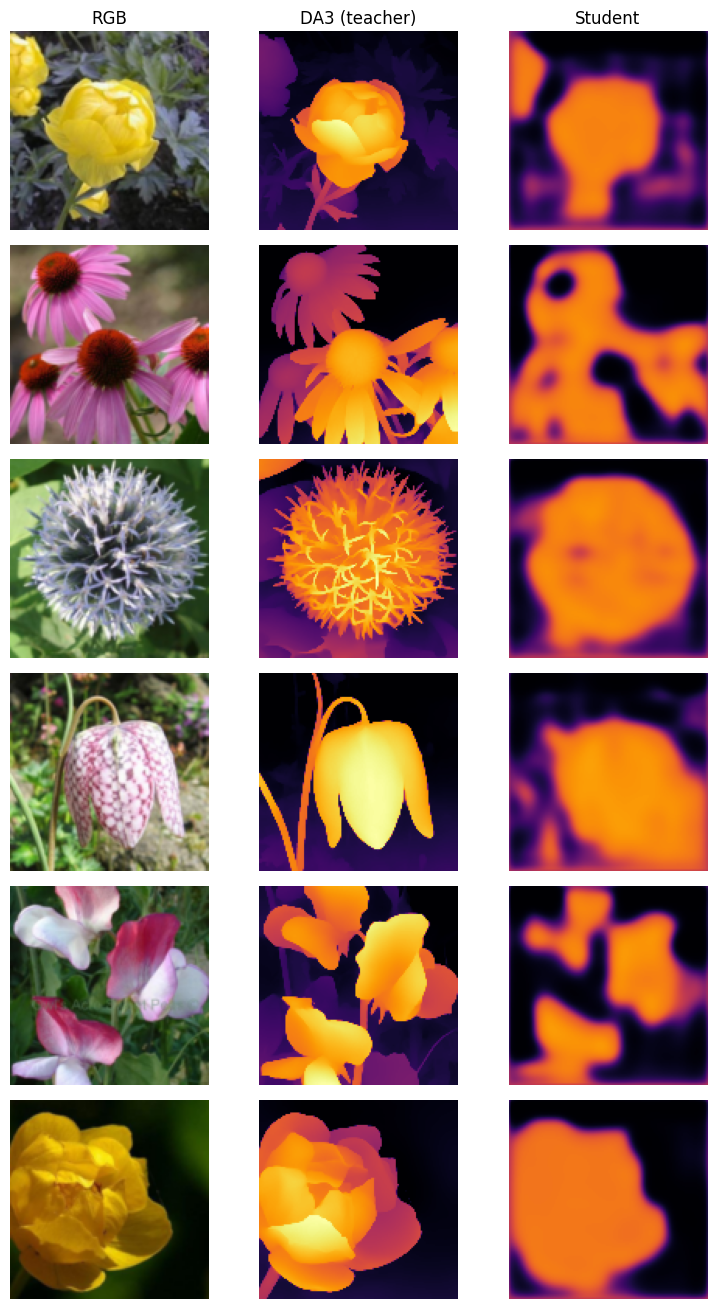

In [15]:
n_show = 6
idxs = list(range(min(n_show, p_all.shape[0])))
val_rgb = torch.stack([val_ds[i][0] for i in idxs])
val_target = torch.stack([val_ds[i][1] for i in idxs])
with torch.no_grad():
    val_pred = student(val_rgb.to(DEVICE)).cpu()

fig, axes = plt.subplots(len(idxs), 3, figsize=(8, 2.2 * len(idxs)))
for r, i in enumerate(idxs):
    axes[r, 0].imshow(val_rgb[r].permute(1, 2, 0).numpy())
    axes[r, 0].set_title("RGB" if r == 0 else "")
    axes[r, 0].axis("off")
    axes[r, 1].imshow(val_target[r].numpy(), cmap="inferno", vmin=0, vmax=1)
    axes[r, 1].set_title("DA3 (teacher)" if r == 0 else "")
    axes[r, 1].axis("off")
    axes[r, 2].imshow(val_pred[r].numpy(), cmap="inferno", vmin=0, vmax=1)
    axes[r, 2].set_title("Student" if r == 0 else "")
    axes[r, 2].axis("off")
plt.tight_layout()
plt.savefig(SYNTH_DIR / "qualitative_comparison.png", dpi=120)
plt.show()

По результатам видно, что student работает лучше простого бейзлайна со «средней картой»:

AbsRel и RMSE у студента ниже;
δ<1.25 и δ<1.25^2 выше;
корреляция Pearson между предсказанием и картой учителя около 0.7–0.85.
=> студент действительно научился повторять структуру карт глубины от DA3. Он обычно правильно отделяет цветок от фона и неплохо передает относительный градиент глубины внутри объекта. Визуально карты похожи на учительские.

Где ок:
Модель подходит для простых изображений формата «объект + фон»(задачи отделения переднего плана от заднего)
В таком узком домене она дает вполне адекватную относительную глубину.

Где не очень ок:
Сложные сцены
Датасет я взяла маленький — около 240 фотографий цветов. Поэтому на сложных indoor-сценах(с большим числом объектов и перекрытий) качество, скорее всего, сильно упадет. Также не подойдет для геометрии(построение point cloud) - обучала one-view depth student, без multi-view геометрии

Результат:
Эксперимент показывает, что подход «большая DA3-модель как учитель -> маленькая модель-студент» работает и на небольших ресурсах. На примерно 200 изображениях и за 25 эпох можно получить разумную модель для относительной  глубины в узком домене. поэтому можно использовать DA3 как генератор псевдо-разметки: она создаёт depth-карты, а маленькая модель учится их повторять.